# Báo cáo giữa kỳ
Dùng keras để xây dựng mô hình deep learning để nhận dạng cat và dog.<br>
Ảnh ví dụ để test mô hình, kích thước của ảnh test sẽ được scale về <strong>224x224</strong>:<br>
<img src="example.jpg" alt="" style="width:224px; heoght:224px"/><br>

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 283s 6s/step - accuracy: 0.5297 - loss: 1.1804 - val_accuracy: 0.5675 - val_loss: 0.6890
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 298s 5s/step - accuracy: 0.5633 - loss: 0.6819 - val_accuracy: 0.6100 - val_loss: 0.6818
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.5870 - loss: 0.6718 - val_accuracy: 0.5450 - val_loss: 0.6659
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 257s 5s/step - accuracy: 0.5972 - loss: 0.6690 - val_accuracy: 0.6125 - val_loss: 0.6613
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.6353 - loss: 0.6459 - val_accuracy: 0.6450 - val_loss: 0.6330
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.6580 - loss: 0.6381 - val_accuracy: 0.6625 - val_loss: 0.6223
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.6605 - loss: 0.6329 - val_accuracy: 0.6750 - val_loss: 0.6134
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.6483 - loss: 0.6430 - val_accuracy: 0.6750 - v

13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7504 - loss: 0.5774
✅ Test Accuracy: 67.50%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


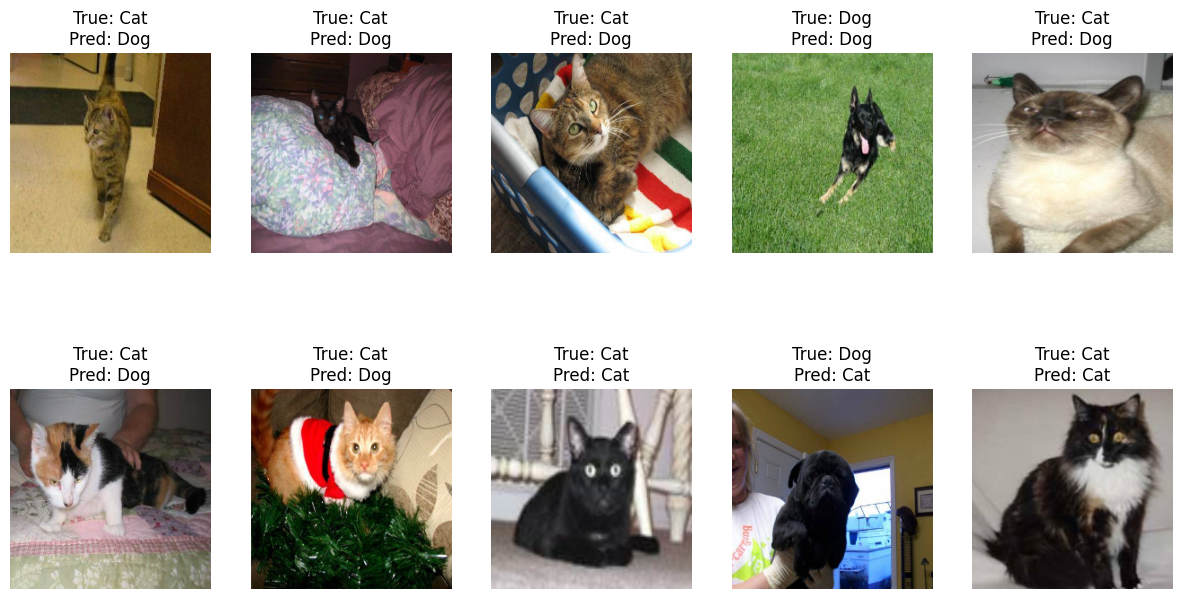

In [ ]:
import os
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Định nghĩa đường dẫn dataset
data_dir = "/content/drive/MyDrive/tgmt va ung dung/animals"

# Tiền xử lý dữ liệu + Data Augmentation để giảm overfitting
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load dữ liệu train và validation
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False  # Không xáo trộn để lấy nhãn đúng khi dự đoán
)

# Xây dựng mô hình CNN với Dropout để tránh overfitting
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),  # Thêm Dropout để giảm overfitting
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
epochs = 10
history = model.fit(train_data, validation_data=val_data, epochs=epochs)

# Lưu mô hình
model.save("animal_classifier.h5")

# Đánh giá trên tập validation
val_loss, val_acc = model.evaluate(val_data)
print(f"✅ Test Accuracy: {val_acc * 100:.2f}%")

# Hàm dự đoán ngẫu nhiên 10 ảnh từ tập validation
def predict_random_images(val_data, model, num_images=10):
    class_labels = list(val_data.class_indices.keys())

    # Chọn 10 ảnh ngẫu nhiên từ tập validation
    random_indices = random.sample(range(len(val_data.filenames)), num_images)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(random_indices):
        img_path = os.path.join(data_dir, val_data.filenames[idx])

        # Đọc và resize ảnh
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Chuẩn bị ảnh để dự đoán
        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        # Dự đoán
        prediction = model.predict(img)[0][0]
        pred_label = "Dog" if prediction > 0.5 else "Cat"
        true_label = "Dog" if 'dog' in val_data.filenames[idx] else "Cat"

        # Hiển thị ảnh
        plt.subplot(2, 5, i+1)
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {pred_label}")

    plt.show()

# Gọi hàm để test
predict_random_images(val_data, model)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
